# Land Cover Classification from Multispectral Imagery

This notebook works through a complete land cover classification: from raw spectral bands to a
classified map, with an honest accuracy assessment at the end.

We use a **synthetic scene** rather than a real Sentinel-2 tile. That is a deliberate choice —
it means this page runs anywhere with no credentials, no multi-gigabyte download, and no
dependence on a data portal staying online. Everything about the workflow is the same as it
would be on real imagery; only the source of the pixels differs. The spectral values used below
are drawn from typical measured surface reflectances, so the band math behaves realistically.

At the end there is a note on what changes when you move to real data.

## Spectral signatures

We simulate five bands, matching the most widely used Sentinel-2 bands:

| Band | Wavelength | Common use |
|---|---|---|
| Blue | 490 nm | atmospheric correction, water |
| Green | 560 nm | vegetation vigor |
| Red | 665 nm | chlorophyll absorption |
| NIR | 842 nm | vegetation structure |
| SWIR | 1610 nm | moisture, burn scars, mineralogy |

Each land cover class has a characteristic reflectance in each band. These four classes —
water, vegetation, bare soil, and built-up — are the standard coarse categories.

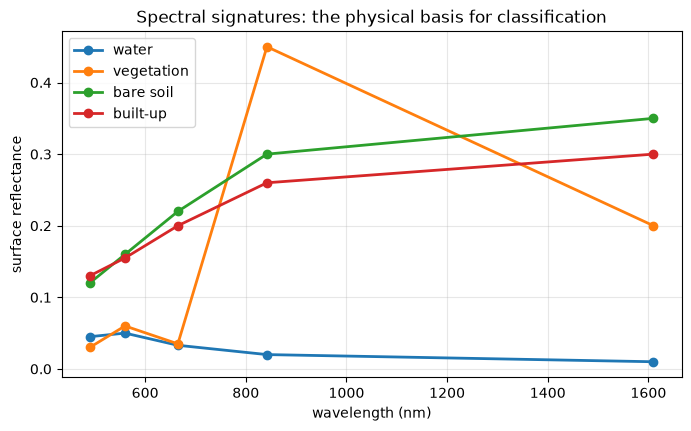

In [1]:
import numpy as np
import matplotlib.pyplot as plt

BANDS = ["Blue", "Green", "Red", "NIR", "SWIR"]
WAVELENGTHS = [490, 560, 665, 842, 1610]
CLASSES = ["water", "vegetation", "bare soil", "built-up"]

# Typical surface reflectance (0-1) per class, per band.
# Note that bare soil and built-up are deliberately similar -- they are genuinely
# hard to separate spectrally, which is a real and well-known problem.
SPECTRA = np.array([
    [0.045, 0.050, 0.033, 0.020, 0.010],   # water: dark, and very dark in NIR/SWIR
    [0.030, 0.060, 0.035, 0.450, 0.200],   # vegetation: the red/NIR jump
    [0.120, 0.160, 0.220, 0.300, 0.350],   # bare soil: rises steadily with wavelength
    [0.130, 0.155, 0.200, 0.260, 0.300],   # built-up: flatter, close to soil
])

plt.figure(figsize=(8, 4.5))
for i, name in enumerate(CLASSES):
    plt.plot(WAVELENGTHS, SPECTRA[i], "o-", lw=2, label=name)
plt.xlabel("wavelength (nm)")
plt.ylabel("surface reflectance")
plt.title("Spectral signatures: the physical basis for classification")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The vegetation curve is the important one. The sharp rise between red (665 nm) and NIR (842 nm)
— the **red edge** — happens because chlorophyll absorbs red light for photosynthesis while
the internal structure of leaves scatters NIR strongly. Nothing else in the scene does this,
which is why vegetation is the easiest class to detect and why the indices below work.

Note also how close **bare soil** and **built-up** are. Keep an eye on those two.

## Building the scene

Real land cover comes in contiguous patches, not scattered pixels. We generate the class map
from smooth random fields so that the result has realistic spatial structure — which, as we
will see at the end, has major consequences for validation.

We also add a smooth **atmospheric haze gradient** across the scene. This is realistic: residual
atmospheric effects, viewing geometry, and illumination all vary spatially across a real tile
and are never perfectly corrected.

In [2]:
def smooth_field(rng, shape, k=4):
    # A random field that varies smoothly in space (sum of low-frequency modes).
    ny, nx = shape
    yy, xx = np.meshgrid(np.linspace(0, 1, ny), np.linspace(0, 1, nx), indexing="ij")
    f = np.zeros(shape)
    for i in range(1, k + 1):
        for j in range(1, k + 1):
            amp = rng.normal() / (i * j)
            p1, p2 = rng.uniform(0, 2 * np.pi, 2)
            f += amp * np.sin(2 * np.pi * i * xx + p1) * np.sin(2 * np.pi * j * yy + p2)
    return (f - f.mean()) / f.std()


rng = np.random.default_rng(11)
shape = (120, 120)

s1 = smooth_field(rng, shape, k=3)
s2 = smooth_field(rng, shape, k=4)

# Assign classes from the smooth fields -> contiguous, realistic patches.
labels = np.full(shape, 2, dtype=int)                       # bare soil by default
labels[s2 > np.percentile(s2, 55)] = 1                      # vegetation
labels[(s1 > np.percentile(s1, 80)) & (s2 < np.percentile(s2, 45))] = 3   # built-up
labels[s1 < np.percentile(s1, 12)] = 0                      # water

# Build the reflectance cube from the class map.
cube = SPECTRA[labels]                                      # (ny, nx, 5)

# Within-class variability (soil moisture, canopy density, roof materials...).
texture = smooth_field(rng, shape, k=8)[..., None]
cube = cube * (1 + 0.18 * texture)

# A smooth haze gradient: additive in the blue, tapering off toward SWIR.
haze = smooth_field(rng, shape, k=2)
haze_spec = np.array([0.030, 0.022, 0.015, 0.008, 0.003])
cube = cube + haze[..., None] * haze_spec

# Sensor noise.
cube = cube + rng.normal(0, 0.010, cube.shape)
cube = np.clip(cube, 0, 1)

counts = np.bincount(labels.ravel(), minlength=4)
for name, c in zip(CLASSES, counts):
    print(f"{name:12} {c:6d} pixels  ({100*c/labels.size:5.1f}%)")

water          1728 pixels  ( 12.0%)
vegetation     5695 pixels  ( 39.5%)
bare soil      5756 pixels  ( 40.0%)
built-up       1221 pixels  (  8.5%)


## True color and false color composites

A **true color** composite maps red/green/blue bands to the display's R/G/B — roughly what the
eye would see. A **false color** composite substitutes NIR for red, which is the standard way to
look at vegetation: healthy vegetation reflects NIR strongly and so appears bright red.

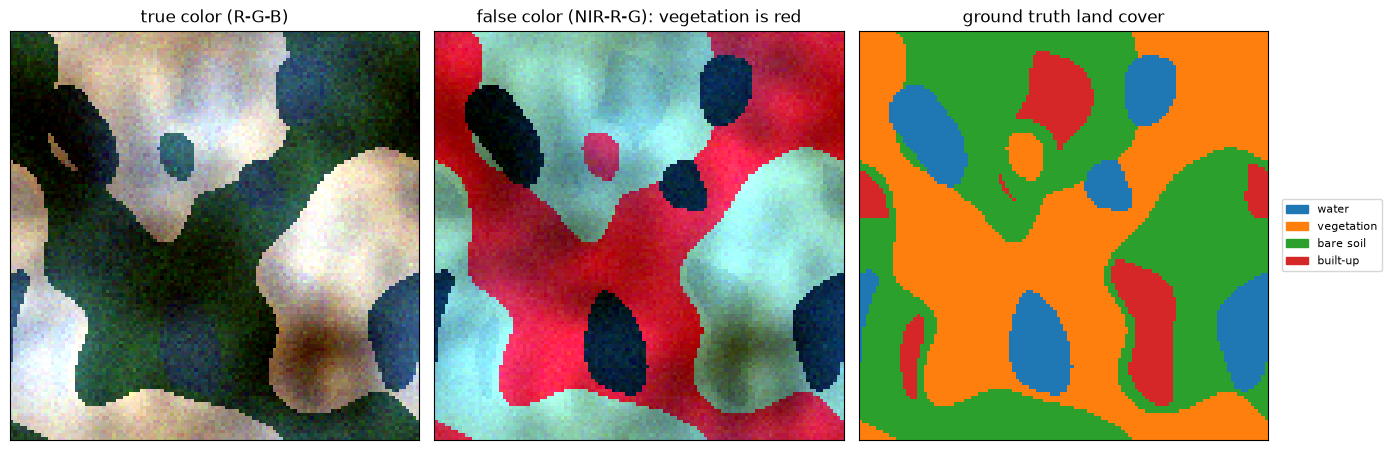

In [3]:
def stretch(x, p=2):
    # Percentile stretch for display -- reflectance values are mostly dark otherwise.
    lo, hi = np.percentile(x, [p, 100 - p])
    return np.clip((x - lo) / (hi - lo + 1e-9), 0, 1)


true_color = np.dstack([stretch(cube[..., 2]), stretch(cube[..., 1]), stretch(cube[..., 0])])
false_color = np.dstack([stretch(cube[..., 3]), stretch(cube[..., 2]), stretch(cube[..., 1])])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
axes[0].imshow(true_color)
axes[0].set_title("true color (R-G-B)")
axes[1].imshow(false_color)
axes[1].set_title("false color (NIR-R-G): vegetation is red")
im = axes[2].imshow(labels, cmap="tab10", vmin=0, vmax=9)
axes[2].set_title("ground truth land cover")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
handles = [plt.Rectangle((0, 0), 1, 1, color=plt.get_cmap("tab10")(i / 9)) for i in range(4)]
axes[2].legend(handles, CLASSES, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

## Spectral indices

Before reaching for a classifier, it is worth knowing how much can be done with band arithmetic
alone. **Spectral indices** are simple ratios designed to isolate a physical property, and they
remain heavily used because they are interpretable, transferable between sensors, and require no
training data.

The best known is **NDVI**, the normalized difference vegetation index:

$$\text{NDVI} = \frac{\rho_{\text{NIR}} - \rho_{\text{Red}}}{\rho_{\text{NIR}} + \rho_{\text{Red}}}$$

The normalization matters: because it is a *ratio*, multiplicative effects such as illumination
and viewing geometry largely cancel. NDVI is far more stable across scenes than raw band values.

We also compute **NDWI** (water) using green and NIR.

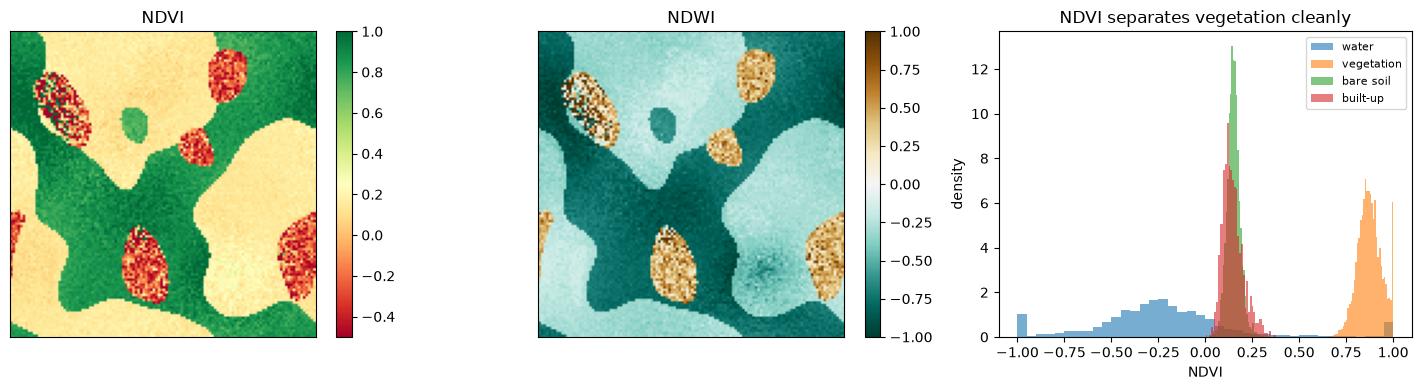

water        mean NDVI = -0.226
vegetation   mean NDVI =  0.875
bare soil    mean NDVI =  0.151
built-up     mean NDVI =  0.147


In [4]:
red, nir, green, swir = cube[..., 2], cube[..., 3], cube[..., 1], cube[..., 4]
ndvi = (nir - red) / (nir + red + 1e-9)
ndwi = (green - nir) / (green + nir + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(ndvi, cmap="RdYlGn", vmin=-0.5, vmax=1)
axes[0].set_title("NDVI")
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(ndwi, cmap="BrBG_r", vmin=-1, vmax=1)
axes[1].set_title("NDWI")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])

for i, name in enumerate(CLASSES):
    axes[2].hist(ndvi[labels == i], bins=40, alpha=0.6, label=name, density=True)
axes[2].set_xlabel("NDVI")
axes[2].set_ylabel("density")
axes[2].set_title("NDVI separates vegetation cleanly")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

for i, name in enumerate(CLASSES):
    print(f"{name:12} mean NDVI = {ndvi[labels==i].mean():6.3f}")

A single threshold on NDVI would separate vegetation from everything else almost perfectly. But
notice that bare soil and built-up have similar NDVI — no single index separates them, which is
where a classifier using the full spectrum earns its place.

## Pixel-wise classification

We now train a random forest on the five spectral bands plus the two indices. This is the
classic approach to land cover mapping and remains a strong, widely used baseline.

We start with the split most people reach for first: a random split over pixels.

random-split test accuracy: 0.9292

              precision    recall  f1-score   support

       water      1.000     1.000     1.000       518
  vegetation      1.000     1.000     1.000      1709
   bare soil      0.881     0.951     0.915      1727
    built-up      0.632     0.393     0.485       366

    accuracy                          0.929      4320
   macro avg      0.878     0.836     0.850      4320
weighted avg      0.921     0.929     0.922      4320



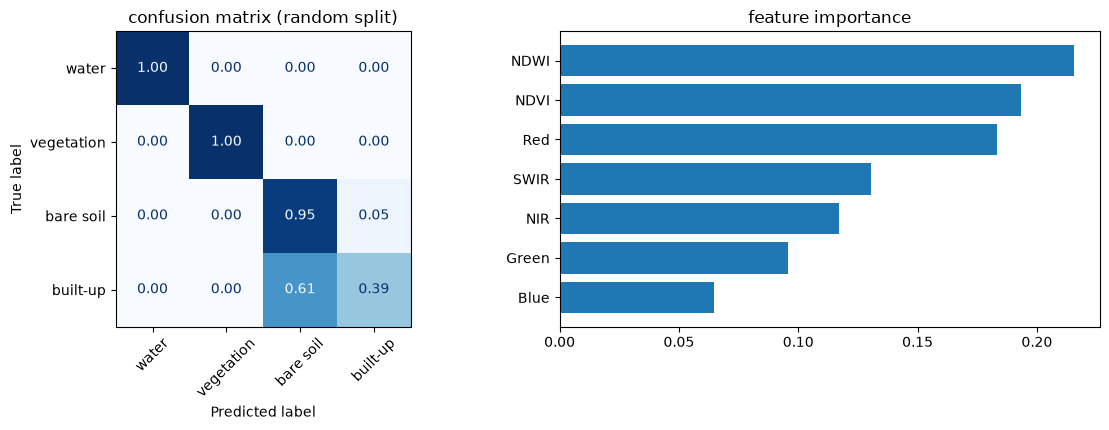

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

features = np.dstack([cube, ndvi[..., None], ndwi[..., None]])
X = features.reshape(-1, features.shape[-1])
y = labels.ravel()
FEATURE_NAMES = BANDS + ["NDVI", "NDWI"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
clf = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1).fit(Xtr, ytr)

print(f"random-split test accuracy: {clf.score(Xte, yte):.4f}\n")
print(classification_report(yte, clf.predict(Xte), target_names=CLASSES, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ConfusionMatrixDisplay.from_predictions(yte, clf.predict(Xte), display_labels=CLASSES,
                                        cmap="Blues", normalize="true", ax=axes[0],
                                        colorbar=False, values_format=".2f")
axes[0].set_title("confusion matrix (random split)")
axes[0].tick_params(axis="x", rotation=45)

order = np.argsort(clf.feature_importances_)
axes[1].barh(np.array(FEATURE_NAMES)[order], clf.feature_importances_[order])
axes[1].set_title("feature importance")
plt.tight_layout()
plt.show()

## How much of that accuracy is real?

Land cover comes in contiguous patches, so a random split over pixels puts each test pixel's
immediate neighbors — same patch, same haze, same texture — into the training set. The model
does not have to learn what vegetation looks like in general; it can partly succeed by
recognizing *this specific patch*.

To measure how much that inflates the score, we cut the scene into contiguous blocks and hold
out whole blocks, then compare.

We also run a second comparison that matters in practice. It is very common to add **pixel
coordinates** as features, on the reasoning that location carries real information about land
cover. Watch what that does to each validation scheme.

                          random CV    block CV       gap
spectral features only  :   0.9317      0.9106    +0.0210
+ pixel coordinates     :   0.9928      0.9468    +0.0460


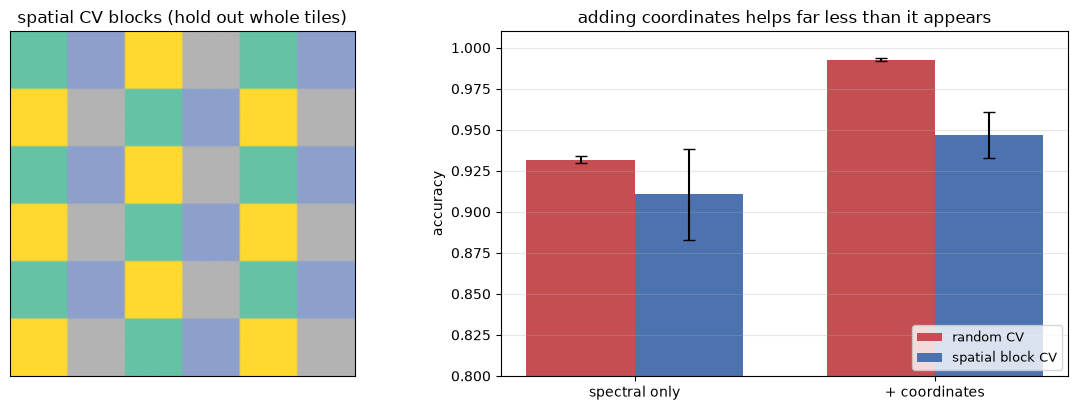

In [6]:
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_score

# 6x6 = 36 contiguous blocks, assigned round-robin to 4 CV groups.
ny, nx = shape
by = (np.arange(ny) // (ny // 6))[:, None]
bx = (np.arange(nx) // (nx // 6))[None, :]
blocks = (by * 6 + bx).ravel()
groups = blocks % 4

# shuffle=True matters here. Passing an integer (cv=4) gives StratifiedKFold
# WITHOUT shuffling, and because the pixels were raveled row by row, those folds
# are contiguous horizontal strips of the image -- accidentally a spatial split
# rather than a random one. This is an easy and silent mistake to make.
random_kf = StratifiedKFold(4, shuffle=True, random_state=0)

rf = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1)
random_cv = cross_val_score(rf, X, y, cv=random_kf, scoring="accuracy")
block_cv = cross_val_score(rf, X, y, cv=GroupKFold(4), groups=groups, scoring="accuracy")

# Repeat with pixel coordinates appended to the spectral features.
yy_i, xx_i = np.mgrid[0:ny, 0:nx]
X_xy = np.column_stack([X, yy_i.ravel() / ny, xx_i.ravel() / nx])
random_xy = cross_val_score(rf, X_xy, y, cv=random_kf, scoring="accuracy")
block_xy = cross_val_score(rf, X_xy, y, cv=GroupKFold(4), groups=groups, scoring="accuracy")

print("                          random CV    block CV       gap")
print(f"spectral features only  :   {random_cv.mean():.4f}      {block_cv.mean():.4f}    {random_cv.mean()-block_cv.mean():+.4f}")
print(f"+ pixel coordinates     :   {random_xy.mean():.4f}      {block_xy.mean():.4f}    {random_xy.mean()-block_xy.mean():+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].imshow(blocks.reshape(shape) % 4, cmap="Set2")
axes[0].set_title("spatial CV blocks (hold out whole tiles)")
axes[0].set_xticks([]); axes[0].set_yticks([])

xpos = np.arange(2)
w = 0.36
axes[1].bar(xpos - w/2, [random_cv.mean(), random_xy.mean()], w,
            yerr=[random_cv.std(), random_xy.std()], capsize=4,
            color="#c44e52", label="random CV")
axes[1].bar(xpos + w/2, [block_cv.mean(), block_xy.mean()], w,
            yerr=[block_cv.std(), block_xy.std()], capsize=4,
            color="#4c72b0", label="spatial block CV")
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(["spectral only", "+ coordinates"])
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0.8, 1.01)
axes[1].legend(loc="lower right", fontsize=9)
axes[1].set_title("adding coordinates helps far less than it appears")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Two results here, and the second is the more interesting one.

**With spectral features only**, the random split is optimistic by a couple of points. Real, but
modest — and that is worth being honest about. The classes in this scene are mostly well
separated spectrally, so there is not much room for the model to gain from memorizing patches.
On real imagery, with more classes, more spectral overlap, and stronger spatial structure, the
gap is typically larger.

**Adding pixel coordinates** appears to be a large improvement: random-split accuracy jumps to
around 99%, close to perfect. But compare the two validation schemes carefully.

Under random CV, coordinates appear to buy about six points of accuracy. Under blocked CV, they
buy roughly half that. So the coordinates are doing two things at once: capturing some genuine
spatial structure (land cover really is geographically organized, and that part generalizes
within the scene) *and* letting the model memorize where things are (which does not generalize
at all). Random CV cannot tell these apart and credits the model for both. Blocked CV separates
them, and shows that a substantial fraction of the apparent gain is lookup rather than learning.

That distinction matters for a decision you would actually make. If you chose between these two
feature sets on the random-CV numbers, coordinates would look like an obvious win. On the
blocked numbers, the win is real but smaller — and if your goal is a model that transfers to a
*different* scene, where the coordinates mean something else entirely, it is not a win at all.
**The validation scheme does not just change your accuracy estimate; it changes which model
you choose.**

## Where the errors actually are

The block-validated confusion matrix tells you something the accuracy number does not: *which*
classes the model confuses.

              precision    recall  f1-score   support

       water      1.000     1.000     1.000      1728
  vegetation      1.000     1.000     1.000      5695
   bare soil      0.874     0.907     0.890      5756
    built-up      0.467     0.387     0.423      1221

    accuracy                          0.911     14400
   macro avg      0.835     0.823     0.828     14400
weighted avg      0.905     0.911     0.907     14400



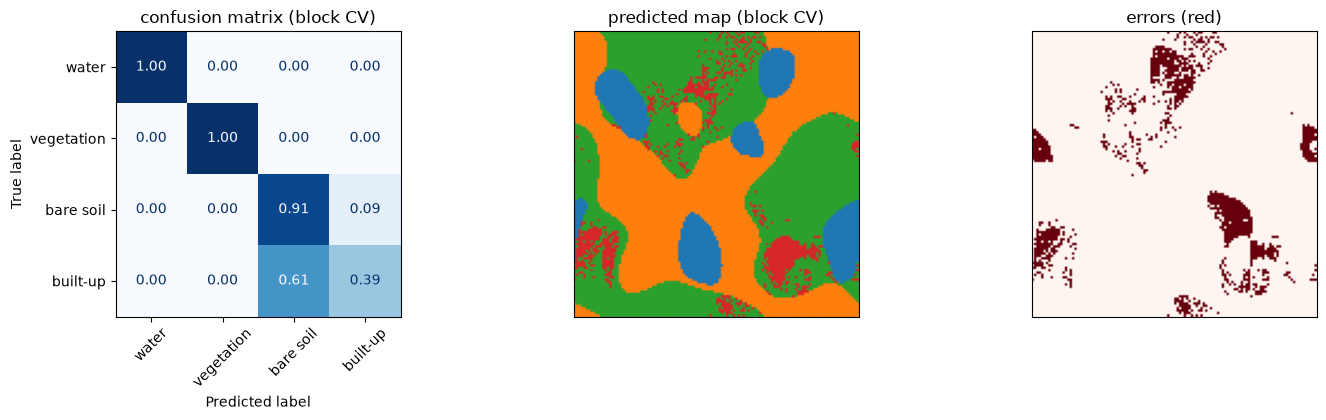

In [7]:
from sklearn.model_selection import cross_val_predict

y_block_pred = cross_val_predict(rf, X, y, cv=GroupKFold(4), groups=groups)

print(classification_report(y, y_block_pred, target_names=CLASSES, digits=3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
ConfusionMatrixDisplay.from_predictions(y, y_block_pred, display_labels=CLASSES,
                                        cmap="Blues", normalize="true", ax=axes[0],
                                        colorbar=False, values_format=".2f")
axes[0].set_title("confusion matrix (block CV)")
axes[0].tick_params(axis="x", rotation=45)
axes[1].imshow(y_block_pred.reshape(shape), cmap="tab10", vmin=0, vmax=9)
axes[1].set_title("predicted map (block CV)")
axes[2].imshow((y_block_pred != y).reshape(shape), cmap="Reds")
axes[2].set_title("errors (red)")
for ax in axes[1:]:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Two things to notice in the error map:

**The errors are spatially clustered**, not scattered. They concentrate at class boundaries and
in particular regions. This is what makes the random split so misleading — errors come in
patches, so holding out random pixels almost guarantees that most held-out pixels sit inside a
patch the model already learned.

**Bare soil and built-up account for most of the confusion**, as their spectra predicted. This
is a genuine limitation of multispectral classification, not a modeling failure. Improving it
requires more information, not a better classifier — texture features, SAR backscatter (built
surfaces scatter radar very differently from soil), seasonal time series (soil changes through
the growing season; parking lots do not), or higher spatial resolution.

That distinction is worth internalizing: some errors are fixed by better models, others only by
better data.

## Moving to real imagery

The workflow above transfers directly. What changes:

**Getting data.** Sentinel-2 and Landsat are free. Common access routes are the Copernicus Data
Space Ecosystem, Microsoft Planetary Computer, AWS Open Data, and Google Earth Engine. The
cloud-hosted STAC catalogs let you pull just the bands and window you need rather than whole
scenes.

**Clouds.** The single biggest practical nuisance in optical remote sensing. A large fraction of
any given scene may be cloud or cloud shadow, and undetected thin cirrus quietly corrupts
results. Scene classification masks ship with the products; use them, and consider compositing
over time to fill gaps.

**Atmospheric correction.** Prefer surface reflectance products (Sentinel-2 L2A, Landsat
Collection 2 L2) over top-of-atmosphere, unless you have a reason not to.

**Labels.** This is the real bottleneck. Existing products — ESA WorldCover, Dynamic World,
NLCD, CORINE — are the usual starting point, but they have their own errors, which become your
labels' errors. Field data is better and far scarcer.

**Class imbalance.** Real landscapes are dominated by a few classes. Rare but important classes
need stratified sampling and metrics beyond accuracy — the subject of the next notebook.

**Validation.** Everything above applies with more force. For a map intended to generalize
across a region, hold out entire scenes or geographic areas, not blocks within one tile.